## Evaluation results visualization

This section loads the CSV files generated by `evaluation/main.py` and visualizes:

- System-level comparison (`summary_all_systems.csv`)
- Per-track distributions (`*.per_track.csv`)
- Onset vs note F1 relationships

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "evaluation").exists() and (repo_root.parent / "evaluation").exists():
    repo_root = repo_root.parent

results_dir = repo_root / "evaluation" / "results"
summary_path = results_dir / "summary_all_systems.csv"

print("Repo root:", repo_root)
print("Results dir:", results_dir)
print("Summary exists:", summary_path.exists())

Repo root: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir
Results dir: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/evaluation/results
Summary exists: True


In [3]:
summary_df = pd.read_csv(summary_path)
summary_df = summary_df.sort_values("note_f1", ascending=False).reset_index(drop=True)
summary_df

,system,est_dir,n_pairs,onset_f1,note_f1,mir_eval_note_f1,onset_precision,onset_recall,note_precision,note_recall,mir_eval_note_precision,mir_eval_note_recall
0,baseline_f0_canteTranscription,noteTranscription/baseline_f0_canteTranscription,20,0.781783,0.424539,0.426888,0.771692,0.809648,0.419835,0.438271,0.419831,0.443759
1,demucs_PESTO_canteTranscription,noteTranscription/demucs_PESTO_canteTranscription,20,0.808517,0.401569,0.397252,0.804842,0.816986,0.399366,0.406034,0.396029,0.400856
2,spleeter_PESTO_canteTranscription,noteTranscription/spleeter_PESTO_canteTranscri...,20,0.786290,0.366322,0.392647,0.779198,0.801334,0.362254,0.373972,0.388594,0.400549
3,demucs_PESTO_transcription,noteTranscription/demucs_PESTO_transcription,20,0.523997,0.123666,0.126762,0.362845,0.975705,0.086473,0.223279,0.088515,0.228957
4,baseline_f0_transcription,noteTranscription/baseline_f0_transcription,20,0.469510,0.115349,0.112657,0.319588,0.949662,0.078812,0.228500,0.075871,0.234182
5,spleeter_PESTO_transcription,noteTranscription/spleeter_PESTO_transcription,20,0.492935,0.114599,0.142861,0.336680,0.958410,0.078775,0.217258,0.098389,0.268595


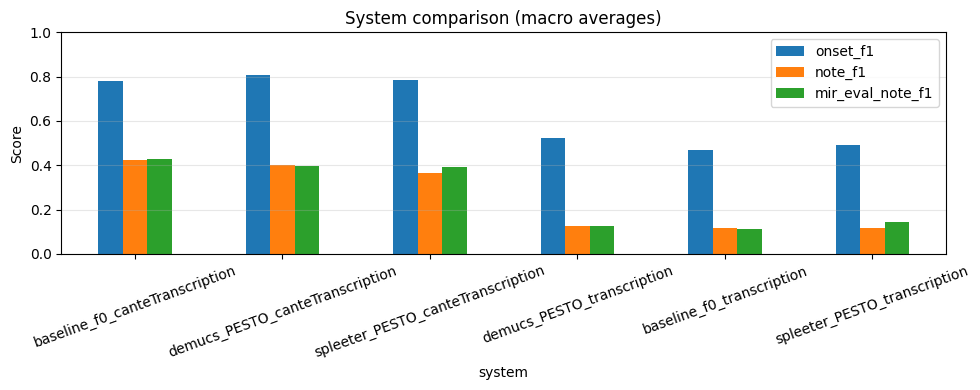

In [4]:
# System-level bar chart: onset_f1, note_f1, mir_eval_note_f1
metrics = ["onset_f1", "note_f1", "mir_eval_note_f1"]
plot_df = summary_df[["system"] + metrics].copy().set_index("system")

ax = plot_df.plot(kind="bar", figsize=(10, 4), rot=20)
ax.set_title("System comparison (macro averages)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Load all per-track files and concatenate
per_track_paths = sorted(results_dir.glob("*.per_track.csv"))
frames = []
for p in per_track_paths:
    df = pd.read_csv(p)
    df["system"] = p.name.replace(".per_track.csv", "")
    frames.append(df)

per_track_df = pd.concat(frames, ignore_index=True)
print("Per-track rows:", len(per_track_df))
per_track_df[["track", "system", "onset_f1", "note_f1", "mir_eval_note_f1"]].head()

Per-track rows: 120


,track,system,onset_f1,note_f1,mir_eval_note_f1
0,01_GabrielMoreno_YoNoTeHeDaoMotivos,baseline_f0_canteTranscription,0.815657,0.429293,0.436869
1,02_BernardoElDeLosLobitos_LosPecesMueranDePena,baseline_f0_canteTranscription,0.619503,0.305927,0.340344
2,03_BernardoElDeLosLobitos_PorLasTrenzasDeTuPelo,baseline_f0_canteTranscription,0.732584,0.319101,0.382022
3,04_AngelDeAlora_LosCaminosEstanMuyMalos,baseline_f0_canteTranscription,0.822917,0.375000,0.380208
4,05_Antonio Mairena_Verguenza,baseline_f0_canteTranscription,0.824926,0.510386,0.504451


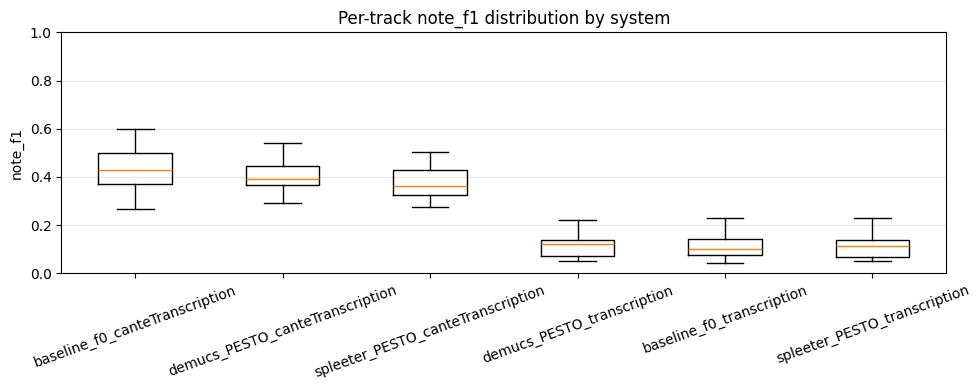

In [6]:
# Boxplot: per-track note_f1 by system
plt.figure(figsize=(10, 4))
order = summary_df["system"].tolist()
box_data = [per_track_df.loc[per_track_df["system"] == s, "note_f1"].dropna().values for s in order]

plt.boxplot(box_data, tick_labels=order, showfliers=False)
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.ylabel("note_f1")
plt.title("Per-track note_f1 distribution by system")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

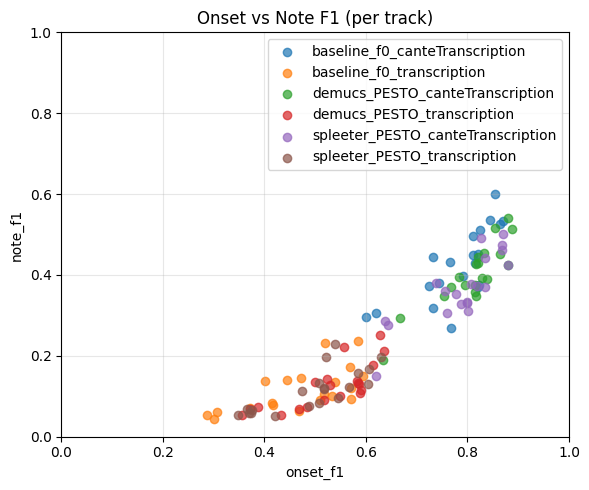

In [7]:
# Scatter: onset_f1 vs note_f1 by system (per track)
plt.figure(figsize=(6, 5))
for system, g in per_track_df.groupby("system"):
    plt.scatter(g["onset_f1"], g["note_f1"], alpha=0.7, label=system)

plt.xlabel("onset_f1")
plt.ylabel("note_f1")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Onset vs Note F1 (per track)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

- Note distribution for the 2 transcriptions + the groundtruth
- Pitch class for the 2 transcriptions + the groundtruth